# Bayesian Linear Regression

## Objective

* Understand the principles of Bayesian Linear Regression.
* Learn the concepts of prior, likelihood, and posterior distributions.
* Implement Bayesian Linear Regression using Python libraries.
* Evaluate predictions and uncertainty estimates.

## Prerequisites

* Basic understanding of Linear Regression
* Probability and Bayes' Theorem
* Knowledge of Python programming
* Familiarity with NumPy and Pandas

## Dataset

The implementation uses a real-world dataset obtained from Kaggle.

## Credits

This notebook was created as part of the Gradientts Machine Learning Internship program.


# Dataset Information

**Dataset Name:** House Prices Dataset

**Kaggle Link:**
https://www.kaggle.com/competitions/house-prices-advanced-regression-techniques/data

**Reason for Selection:**
This dataset is widely used for regression tasks and demonstrates prediction with uncertainty.

**Credits:** Kaggle

In [1]:
# Numerical computations
import numpy as np

# Data manipulation
import pandas as pd

# Data visualization
import matplotlib.pyplot as plt

# Train-test split and metrics
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score

# Bayesian Linear Regression
from sklearn.linear_model import BayesianRidge

In [2]:
# Load the dataset
df = pd.read_csv("data/train.csv")

# Display the first 5 rows
df.head()

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


## Dataset Exploration

The House Prices dataset contains information about residential homes along with their selling prices. Before training the Bayesian Linear Regression model, we explore the dataset structure, identify important features, and check for missing values.

In [3]:
print("Dataset Shape:", df.shape)

print("\nColumn Names:")
print(df.columns.tolist())

print("\nMissing Values:")
print(df.isnull().sum().sort_values(ascending=False).head())

print("\nSummary Statistics:")
display(df.describe())

Dataset Shape: (1460, 81)

Column Names:
['Id', 'MSSubClass', 'MSZoning', 'LotFrontage', 'LotArea', 'Street', 'Alley', 'LotShape', 'LandContour', 'Utilities', 'LotConfig', 'LandSlope', 'Neighborhood', 'Condition1', 'Condition2', 'BldgType', 'HouseStyle', 'OverallQual', 'OverallCond', 'YearBuilt', 'YearRemodAdd', 'RoofStyle', 'RoofMatl', 'Exterior1st', 'Exterior2nd', 'MasVnrType', 'MasVnrArea', 'ExterQual', 'ExterCond', 'Foundation', 'BsmtQual', 'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinSF1', 'BsmtFinType2', 'BsmtFinSF2', 'BsmtUnfSF', 'TotalBsmtSF', 'Heating', 'HeatingQC', 'CentralAir', 'Electrical', '1stFlrSF', '2ndFlrSF', 'LowQualFinSF', 'GrLivArea', 'BsmtFullBath', 'BsmtHalfBath', 'FullBath', 'HalfBath', 'BedroomAbvGr', 'KitchenAbvGr', 'KitchenQual', 'TotRmsAbvGrd', 'Functional', 'Fireplaces', 'FireplaceQu', 'GarageType', 'GarageYrBlt', 'GarageFinish', 'GarageCars', 'GarageArea', 'GarageQual', 'GarageCond', 'PavedDrive', 'WoodDeckSF', 'OpenPorchSF', 'EnclosedPorch', '3SsnPo

,Id,MSSubClass,LotFrontage,LotArea,OverallQual,OverallCond,YearBuilt,YearRemodAdd,MasVnrArea,BsmtFinSF1,...,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,MiscVal,MoSold,YrSold,SalePrice
count,1460.000000,1460.000000,1201.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1452.000000,1460.000000,...,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000
mean,730.500000,56.897260,70.049958,10516.828082,6.099315,5.575342,1971.267808,1984.865753,103.685262,443.639726,...,94.244521,46.660274,21.954110,3.409589,15.060959,2.758904,43.489041,6.321918,2007.815753,180921.195890
std,421.610009,42.300571,24.284752,9981.264932,1.382997,1.112799,30.202904,20.645407,181.066207,456.098091,...,125.338794,66.256028,61.119149,29.317331,55.757415,40.177307,496.123024,2.703626,1.328095,79442.502883
min,1.000000,20.000000,21.000000,1300.000000,1.000000,1.000000,1872.000000,1950.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,2006.000000,34900.000000
25%,365.750000,20.000000,59.000000,7553.500000,5.000000,5.000000,1954.000000,1967.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,5.000000,2007.000000,129975.000000
50%,730.500000,50.000000,69.000000,9478.500000,6.000000,5.000000,1973.000000,1994.000000,0.000000,383.500000,...,0.000000,25.000000,0.000000,0.000000,0.000000,0.000000,0.000000,6.000000,2008.000000,163000.000000
75%,1095.250000,70.000000,80.000000,11601.500000,7.000000,6.000000,2000.000000,2004.000000,166.000000,712.250000,...,168.000000,68.000000,0.000000,0.000000,0.000000,0.000000,0.000000,8.000000,2009.000000,214000.000000
max,1460.000000,190.000000,313.000000,215245.000000,10.000000,9.000000,2010.000000,2010.000000,1600.000000,5644.000000,...,857.000000,547.000000,552.000000,508.000000,480.000000,738.000000,15500.000000,12.000000,2010.000000,755000.000000


## Feature Selection

To simplify the implementation while still using a real-world dataset, we select a subset of important numerical features that have a strong relationship with house prices.

In [4]:
selected_features = [
    'GrLivArea',
    'OverallQual',
    'GarageCars',
    'TotalBsmtSF'
]

X = df[selected_features]

y = df['SalePrice']

X.head()

,GrLivArea,OverallQual,GarageCars,TotalBsmtSF
0,1710,7,2,856
1,1262,6,2,1262
2,1786,7,2,920
3,1717,7,3,756
4,2198,8,3,1145


In [5]:
print("Missing values before handling:")
print(X.isnull().sum())

X = X.fillna(X.median())

print("\nMissing values after handling:")
print(X.isnull().sum())

Missing values before handling:
GrLivArea      0
OverallQual    0
GarageCars     0
TotalBsmtSF    0
dtype: int64

Missing values after handling:
GrLivArea      0
OverallQual    0
GarageCars     0
TotalBsmtSF    0
dtype: int64


In [6]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("Training Feature Shape:", X_train.shape)
print("Testing Feature Shape:", X_test.shape)
print("Training Target Shape:", y_train.shape)
print("Testing Target Shape:", y_test.shape)

Training Feature Shape: (1168, 4)
Testing Feature Shape: (292, 4)
Training Target Shape: (1168,)
Testing Target Shape: (292,)


## Bayesian Linear Regression: Conceptual Implementation (From Scratch)

Bayesian Linear Regression combines prior beliefs about model parameters with observed data to obtain updated beliefs.

Bayes' Theorem:

Posterior ∝ Likelihood × Prior

This section demonstrates the fundamental concepts behind Bayesian Linear Regression before using scikit-learn's implementation.

In [7]:
# Prior beliefs

prior_mean = 0

prior_variance = 1

print("Prior Mean:", prior_mean)

print("Prior Variance:", prior_variance)

Prior Mean: 0
Prior Variance: 1


### Likelihood

The likelihood represents how probable the observed data is, given the model parameters.

In Bayesian Linear Regression, the likelihood is combined with the prior distribution to obtain the posterior distribution.

### Posterior Distribution

The posterior distribution represents the updated belief about the model parameters after observing the data.

A complete implementation of Bayesian inference requires advanced probabilistic techniques. Therefore, the practical implementation below uses scikit-learn's `BayesianRidge`.

## Bayesian Linear Regression

Bayesian Linear Regression incorporates prior beliefs about model parameters and updates these beliefs using observed data. This approach provides both predictions and uncertainty estimates.

In [8]:
# Create the model
model = BayesianRidge()

# Train the model
model.fit(X_train, y_train)

print("Bayesian Linear Regression model trained successfully!")

Bayesian Linear Regression model trained successfully!


## Model Evaluation

After training the Bayesian Linear Regression model, we evaluate its performance using Mean Squared Error (MSE), Root Mean Squared Error (RMSE), and R² Score.

In [9]:
# Make predictions
y_pred = model.predict(X_test)

# Calculate metrics
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print("Mean Squared Error (MSE):", round(mse, 2))
print("Root Mean Squared Error (RMSE):", round(rmse, 2))
print("R² Score:", round(r2, 4))

Mean Squared Error (MSE): 1601661378.26
Root Mean Squared Error (RMSE): 40020.76
R² Score: 0.7912


## Actual vs Predicted House Prices

This visualization compares the actual house prices with the prices predicted by the Bayesian Linear Regression model.

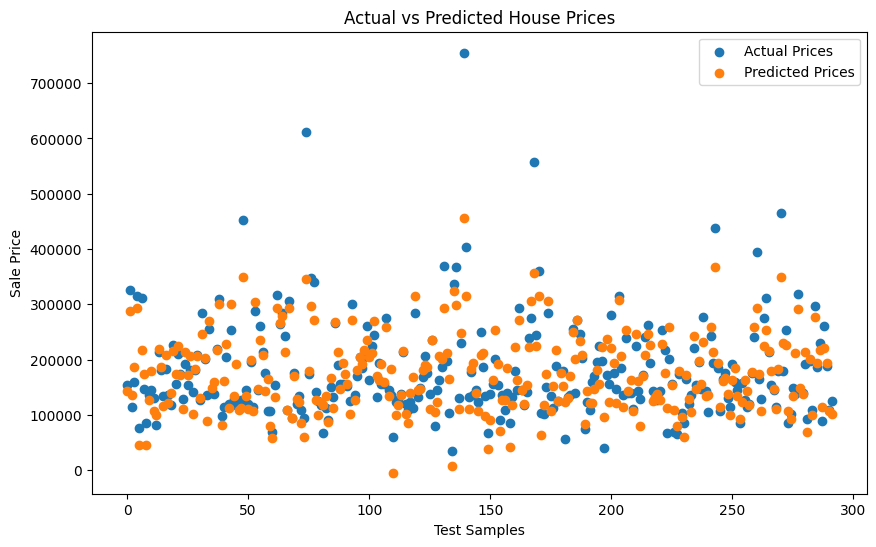

In [10]:
plt.figure(figsize=(10, 6))

plt.scatter(
    range(len(y_test)),
    y_test,
    label='Actual Prices'
)

plt.scatter(
    range(len(y_pred)),
    y_pred,
    label='Predicted Prices'
)

plt.title('Actual vs Predicted House Prices')
plt.xlabel('Test Samples')
plt.ylabel('Sale Price')
plt.legend()

plt.show()

## Model Coefficients

The coefficients indicate the influence of each feature on the predicted house price.

In [11]:
coefficients = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': model.coef_
})

display(coefficients)

,Feature,Coefficient
0,GrLivArea,42.982317
1,OverallQual,23696.440429
2,GarageCars,19335.096386
3,TotalBsmtSF,28.584819


## Hyperparameter Experiment

Bayesian Linear Regression uses prior distributions. Here, we experiment with different values of the regularization parameter `alpha_1`.

In [12]:
alpha_values = [1e-6, 1e-5, 1e-4]

for alpha in alpha_values:
    
    experiment_model = BayesianRidge(alpha_1=alpha)
    
    experiment_model.fit(X_train, y_train)
    
    predictions = experiment_model.predict(X_test)
    
    score = r2_score(y_test, predictions)
    
    print(f"alpha_1 = {alpha}: R² Score = {score:.4f}")

alpha_1 = 1e-06: R² Score = 0.7912
alpha_1 = 1e-05: R² Score = 0.7912
alpha_1 = 0.0001: R² Score = 0.7912


## Interview Corner

### Question:
What is the key difference between Linear Regression and Bayesian Linear Regression?

### Answer:
Linear Regression produces a single estimate for model parameters, whereas Bayesian Linear Regression treats parameters as probability distributions and updates beliefs using observed data.

## Key Takeaways

1. Bayesian Linear Regression incorporates uncertainty into predictions.
2. Prior beliefs are updated using observed data to form posterior distributions.
3. The model provides probabilistic interpretations of parameters.
4. Evaluation metrics such as RMSE and R² help assess performance.
5. Bayesian approaches can reduce overfitting compared to traditional regression methods.

## Bayes' Theorem

Posterior ∝ Likelihood × Prior

Where:
- Prior = initial belief
- Likelihood = evidence from data
- Posterior = updated belief

### Significance
Allows predictions with uncertainty estimates.